In [1]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231113'
prefix_uptake = '20240321'
prefix_list = [prefix_default, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list = ['UQ_20231113'] # , 'UQ_20240312_test20241017']
N_list = [4000] # , 3125]
BLOCK_LIST = [200] # , 125]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'HR', 'NEE'] # , 'TOTSOMC']

collection_obs = uq_get_obs(VAR_LIST)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

collection_sim_target = {}
for prefix in [prefix_default, prefix_uptake]:
    collection_sim_target[prefix] = uq_get_sim(prefix, VAR_LIST)

/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1115: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']
/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1115: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']


/tmp/ipykernel_2840760/3584452539.py:100: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-or" (-> color='r'). The keyword argument will take precedence.
  h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])


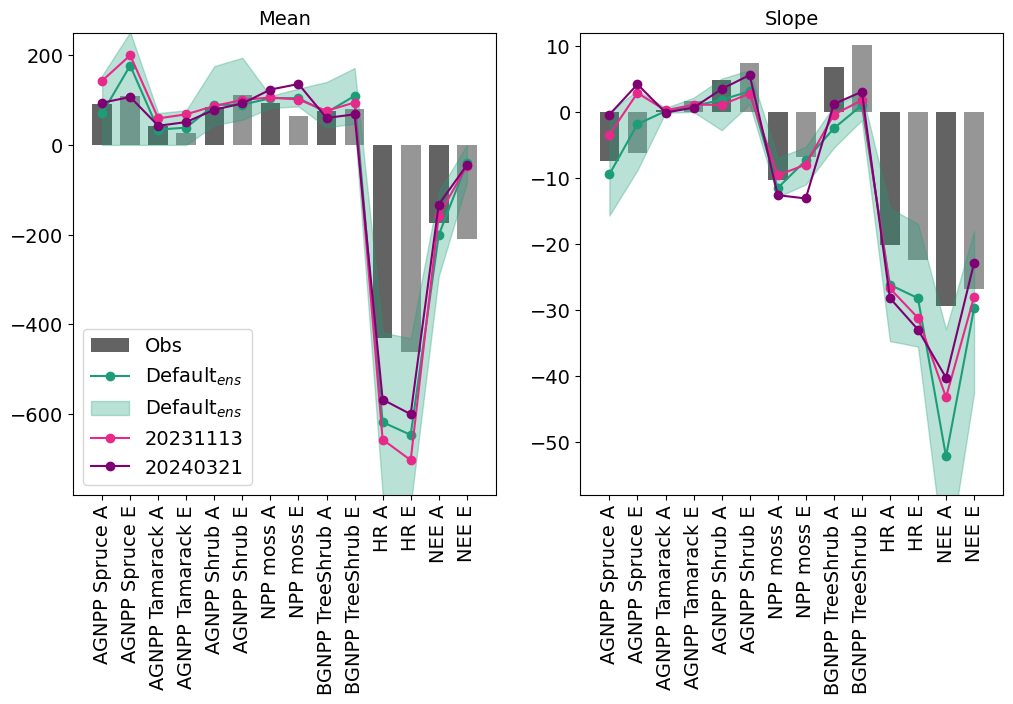

In [3]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','HR','NEE']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
n_best_ind = 50
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
sims_target_mean = {}
sims_target_slope = {}
for prefix in collection_sim_target:
    sims_target_mean[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 0].reshape(1, -1)
    sims_target_slope[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 2].reshape(1, -1)

#
fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharex = True)
ax = axes[0]
h1 = ax.bar(np.arange(obs_mean.shape[1]), obs_mean[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax.set_title('Mean')
ax = axes[1]
h1 = ax.bar(np.arange(obs_slope.shape[1]), obs_slope[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax.set_title('Slope')

clist = ['#1b9e77', '#d95f02', '#e7298a', '#800074'] # '#1a80bb'
h2 = [None] * len(prefix_list)
h3 = [None] * len(prefix_list)
for p, prefix in enumerate(prefix_list):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    # find the best runs
    rmse_mean = np.sqrt(np.mean(np.power((sim_mean - obs_mean) / \
                                        (np.abs(obs_mean)) * 2, 2),
                                axis = 1))
    rmse_slope = np.sqrt(np.mean(np.power((sim_slope - obs_slope) / \
                                        (np.abs(obs_slope)) * 2, 2),
                                axis = 1))
    rmse_tot = np.sqrt((rmse_mean**2 + rmse_slope**2)/2)
    best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    ax = axes[0]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_mean[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_mean[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_mean[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_mean[2851, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_mean_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_mean_bi.shape[1]), 
                            np.min(sim_mean_bi, axis = 0),
                            np.max(sim_mean_bi, axis = 0), color = clist[p], alpha = 0.3)

    ax.set_xticks(np.arange(sim_mean_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-780, 250])

    ax = axes[1]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_slope[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_slope[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_slope[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241013':
        h2[p], = ax.plot(sim_slope[900, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_slope[2851, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_slope_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_slope_bi.shape[1]), 
                            np.min(sim_slope_bi, axis = 0),
                            np.max(sim_slope_bi, axis = 0), color = clist[p], alpha = 0.3)
    ax.set_xticks(np.arange(sim_slope_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-58, 12])

h4 = [None] * 2
for p, prefix in enumerate([prefix_default, prefix_uptake]):
    ax = axes[0]
    h4[p], = ax.plot(sims_target_mean[prefix][0, :], '-o', color = clist[2 + p])
    ax = axes[1]
    h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])

ax = axes[0]
ax.legend([h1] + h2 + h3 + h4, ['Obs', 'Default$_{ens}$'] + \
          ['NU ' + p.split('_')[-1] for p in prefix_list[1:]] + \
          ['Default$_{ens}$'] + ['NU$_{ens}$' + p.split('_')[-1] for p in prefix_list[1:]] + 
          [f'{prefix_default}', f'{prefix_uptake}'],
          loc = 'lower left')